## Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

listings = pd.read_csv("data\\processed\\CRMLSListing_Residential.csv", low_memory=False)
sold = pd.read_csv("data\\processed\\CRMLSSold_Residential.csv", low_memory=False)

pd.set_option('display.max_rows', None)

### Basics: Understanding the Structure, Missing Values, Distributions

In [3]:
print(f"Listing Size: {listings.shape}\n")
listings.head()

Listing Size: (644458, 84)



,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


In [4]:
print(f"Sold Size: {sold.shape}\n")
sold.head()

Sold Size: (480487, 84)



,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,94401,6472.0,NaN,NaN,True,True,NaN,NaN,NaN,NaN
1,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
2,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,91950,NaN,NaN,NaN,True,True,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,False,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,93401,0.0,11219.0,NaN,False,False,NaN,NaN,NaN,NaN
4,Tile,True,NaN,NaN,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,95437,NaN,74487.6,NaN,False,False,NaN,NaN,NaN,NaN


#### Columns, Data Types, Missing Value Analysis

In [5]:
list_null = pd.DataFrame({
    'Dtype': listings.dtypes,
    'Null Count': listings.isnull().sum(),
    'Null Pct (%)': (listings.isnull().sum() / len(listings)) * 100
})

print("LISTINGS -------------------------------------------------------")
print(list_null)

sold_null = pd.DataFrame({
    'Dtype': sold.dtypes,
    'Null Count': sold.isnull().sum(),
    'Null Pct (%)': (sold.isnull().sum() / len(sold)) * 100
})

print("\nSOLD -----------------------------------------------------------")
print(sold_null)

LISTINGS -------------------------------------------------------
                                Dtype  Null Count  Null Pct (%)
OriginalListPrice             float64         931      0.144462
ListingKey                      int64           0      0.000000
ListAgentEmail                 object      100520     15.597603
CloseDate                      object      428707     66.522101
ClosePrice                    float64      451293     70.026751
ListAgentFirstName             object        4916      0.762812
ListAgentLastName              object          49      0.007603
Latitude                      float64       81206     12.600666
Longitude                     float64       81206     12.600666
UnparsedAddress                object         970      0.150514
PropertyType                   object           0      0.000000
LivingArea                    float64         621      0.096360
ListPrice                     float64           0      0.000000
DaysOnMarket                    int64  

In [6]:
print("Null Percentages over 90% in Listings:")
print(list_null[list_null["Null Pct (%)"] > 90])
print("\nNull Percentages over 90% in Sold:")
print(sold_null[sold_null["Null Pct (%)"] > 90])

Null Percentages over 90% in Listings:
                                Dtype  Null Count  Null Pct (%)
FireplacesTotal               float64      644458    100.000000
AboveGradeFinishedArea        float64      644458    100.000000
TaxAnnualAmount               float64      644458    100.000000
BuilderName                    object      614796     95.397373
TaxYear                       float64      644458    100.000000
BuildingAreaTotal             float64      587998     91.239150
ElementarySchoolDistrict      float64      644458    100.000000
CoBuyerAgentFirstName          object      625193     97.010666
BelowGradeFinishedArea        float64      640646     99.408495
BusinessType                  float64      644458    100.000000
CoveredSpaces                 float64      644458    100.000000
LotSizeDimensions              object      610871     94.788334
MiddleOrJuniorSchoolDistrict  float64      644458    100.000000

Null Percentages over 90% in Sold:
                             

All variables that have 100\% missingness will be dropped as they add no value to the analysis. Those with over 99\% will also be dropped. This includes (from both datasets):

1. FireplacesTotal
2. AboveGradeFinishedArea
3. TaxAnnualAmount
4. TaxYear
5. ElementarySchoolDistrict
6. BusinessType
7. CoveredSpaces
8. MiddleOrJuniorSchoolDistrict
9. BelowGradeFinishedArea
10. WaterfrontYN (from Sold)

Some other variables to drop include:
1. BuilderName - the build is not the focus of this analysis
2. BuildingAreaTotal - there are more populated, similar fields like LivingArea
3. LotSizeDimensions - there are more populated, similar fields like LotSizeSquareFeette columns that should be removed
4. CoBuyerAgentFirstName - no identification besides first name, also high missingness

For other columns, we dig into what the null values mean.

In [7]:
print("BASEMENTYN (SOLD) --------------------------------------------")
basement = sold["BasementYN"]
print(basement.unique())
basement = basement[basement.notna()]
print(basement.sum())

print("WATERFRONTYN (SOLD) ------------------------------------------")
waterfront = sold["WaterfrontYN"]
print(waterfront.unique())
waterfront = waterfront[waterfront.notna()]
print(waterfront.sum())

BASEMENTYN (SOLD) --------------------------------------------
[nan True]
9425
WATERFRONTYN (SOLD) ------------------------------------------
[nan True]
301


For BasementYN and WaterfrontYN in the Sold dataset, we find that the only values entered are "True". This suggests that the missing values may represent "False" as well as missed positives. These columns may be useful in identifying factors that drove sales, so we keep them for now. 

#### Distributions

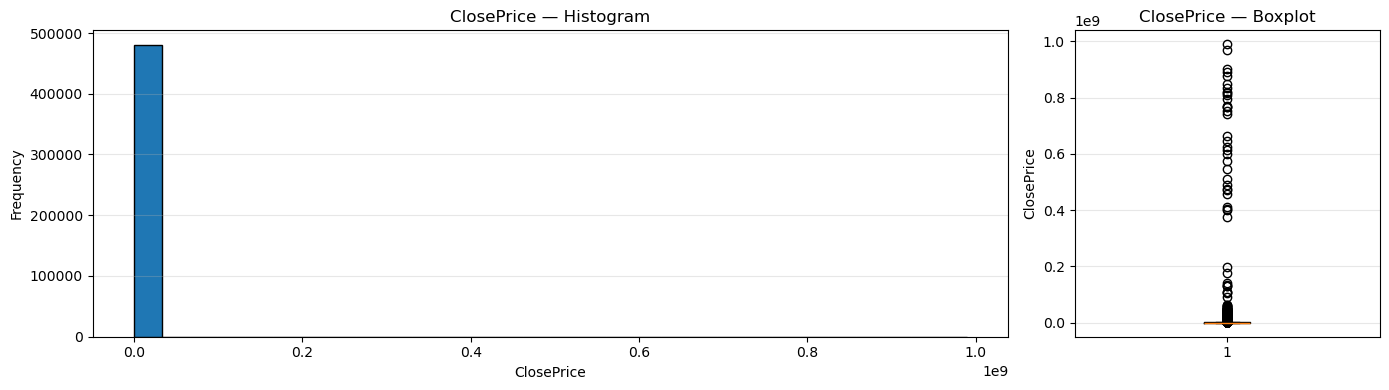

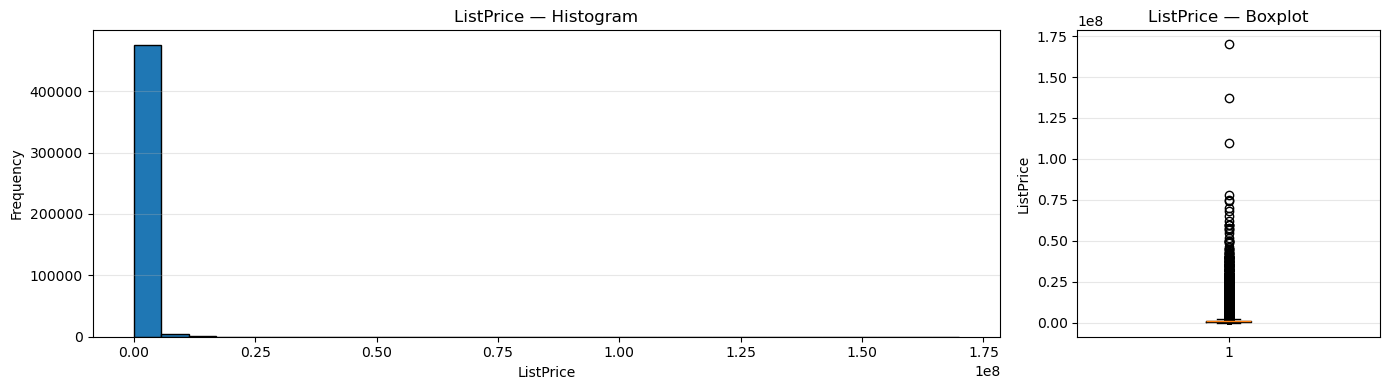

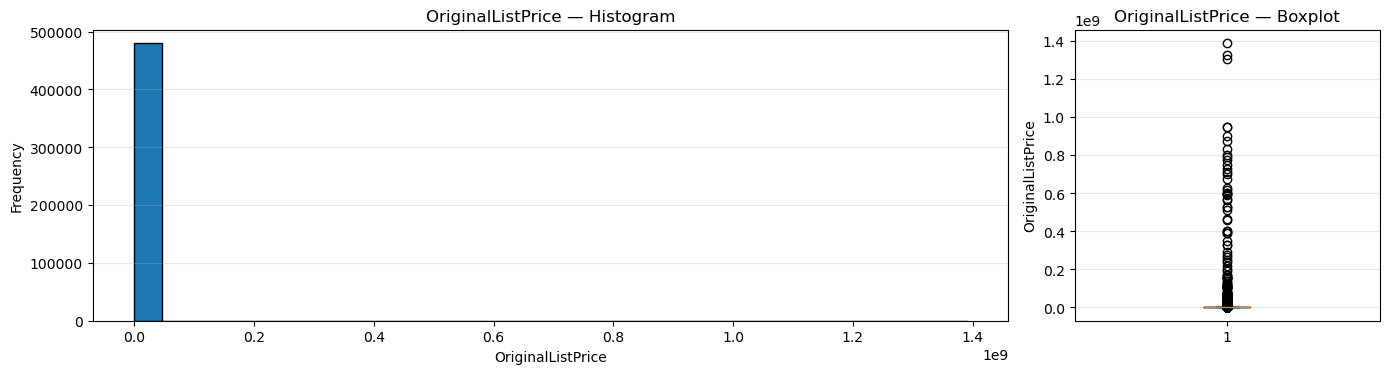

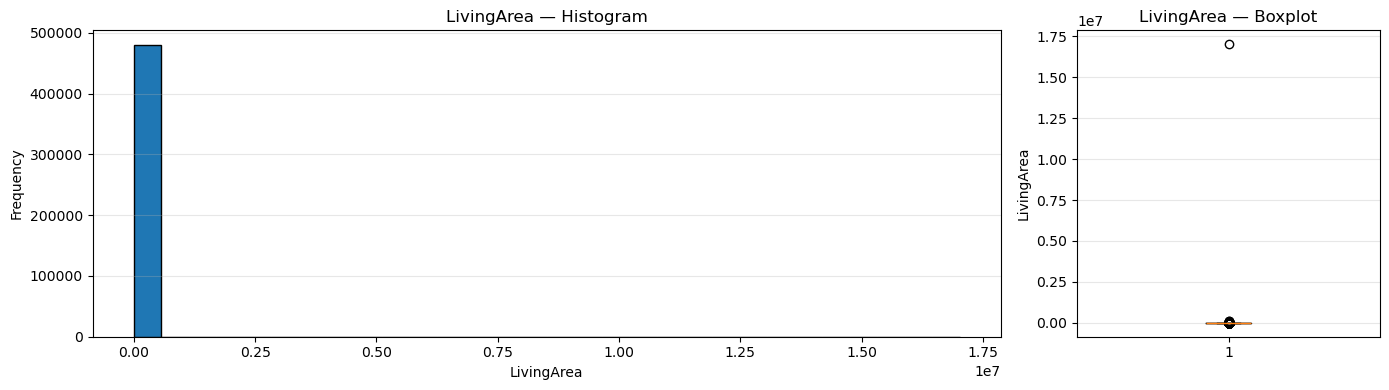

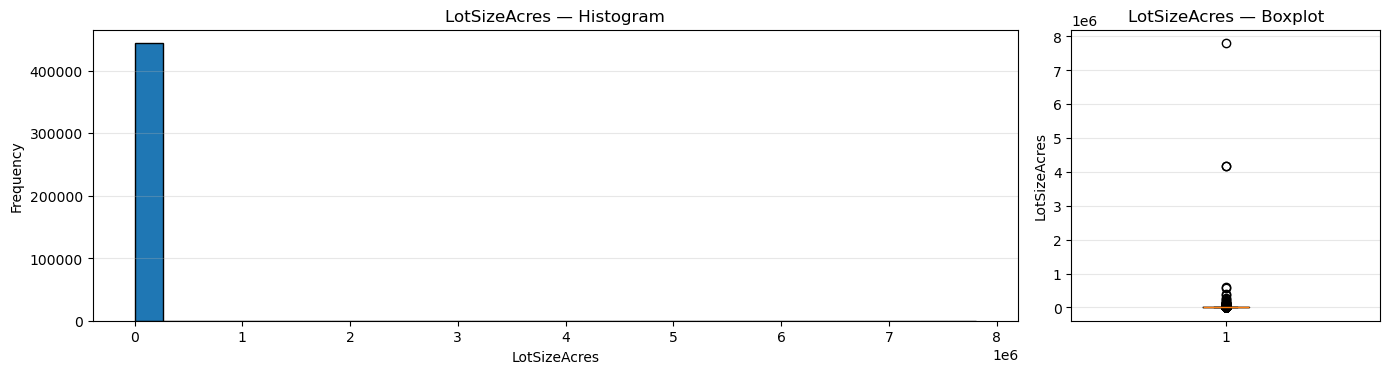

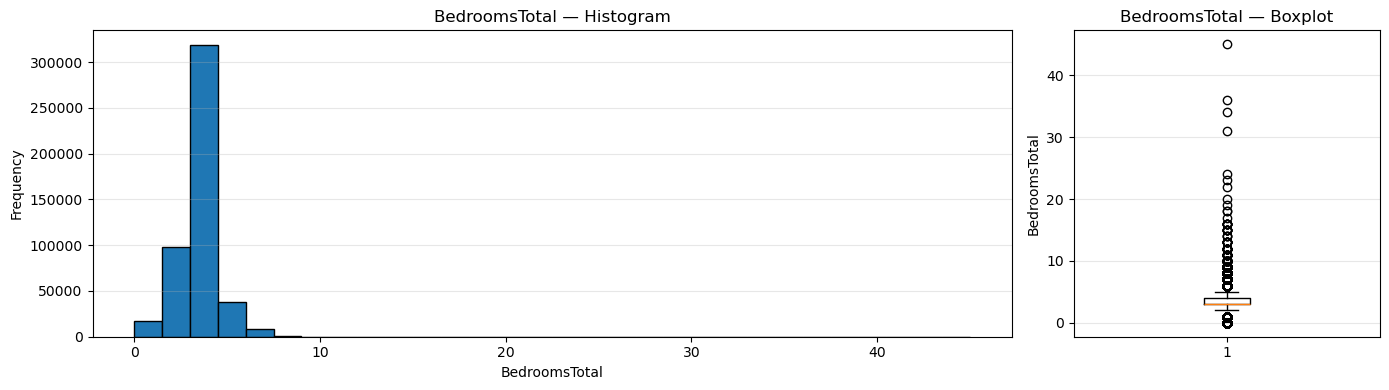

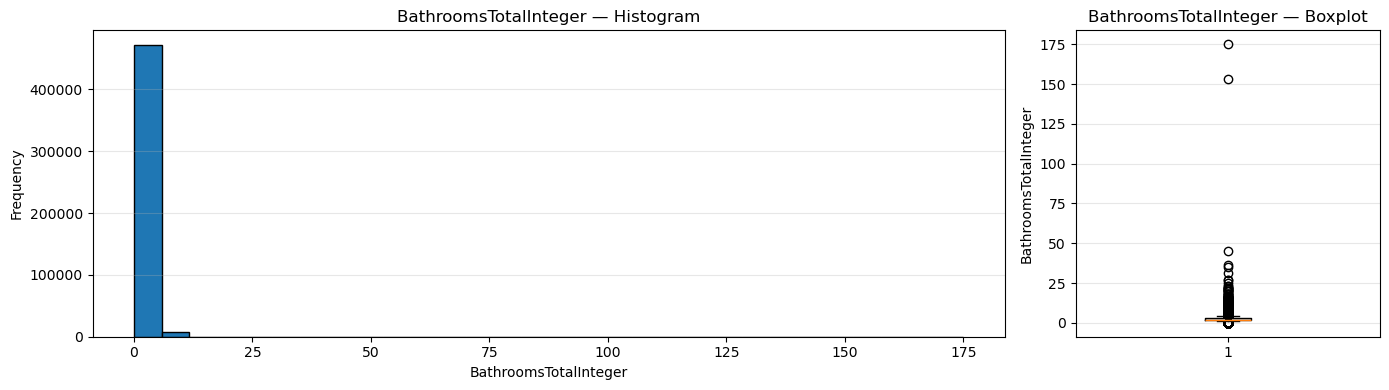

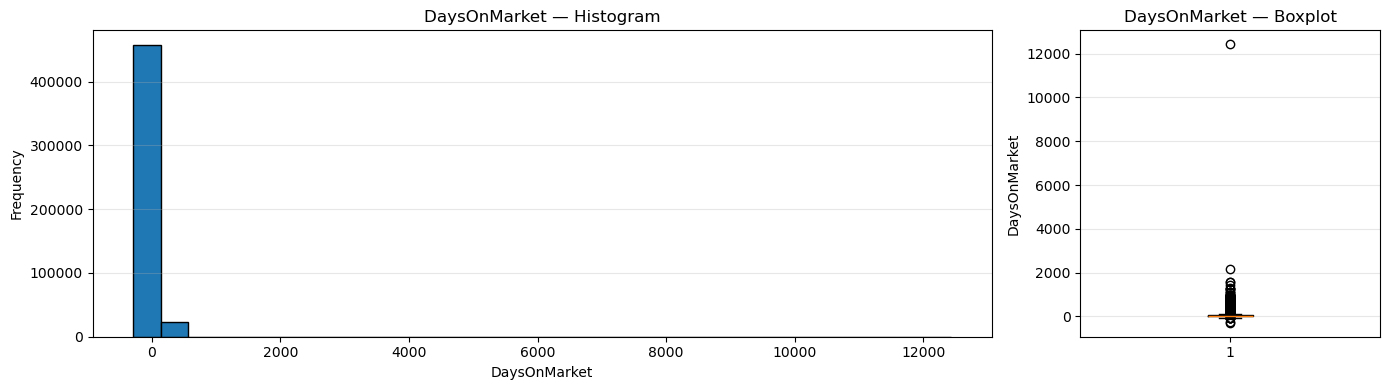

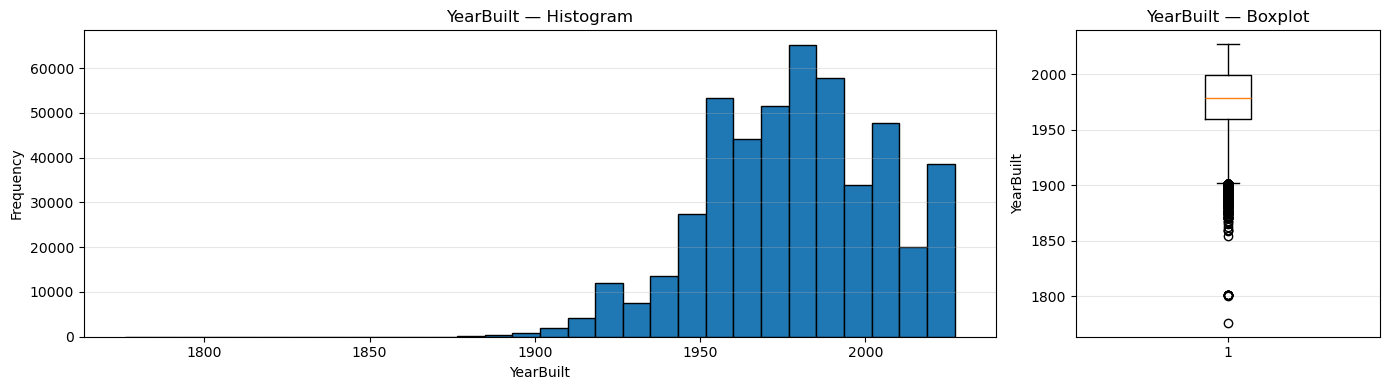

In [8]:
numeric_fields = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea", "LotSizeAcres", 
                 "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]
                 
for variable in numeric_fields:
    data = sold[variable].dropna()

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 4),
        gridspec_kw={"width_ratios": [3, 1]}
    )

    axes[0].hist(data, bins=30, edgecolor="black")
    axes[0].set_title(f"{variable} — Histogram")
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].boxplot(data, vert=True)
    axes[1].set_title(f"{variable} — Boxplot")
    axes[1].set_ylabel(variable)
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [9]:
percentiles = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]

summary = pd.DataFrame({var: sold[var].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99])
     for var in numeric_fields}).T

summary = summary[["count", "mean", "std", "min",
     "1%", "5%", "10%", "25%", "50%", "75%", "90%", "95%", "99%", "max"]]

display(summary)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ClosePrice,480485.0,1.189588e+06,5.864013e+06,0.0,200000.0,339000.00,415000.0000,575000.00,825000.0000,1.300000e+06,2.075000e+06,2850000.00,5600000.000,9.895000e+08
ListPrice,480487.0,1.144405e+06,1.395351e+06,1.0,210000.0,345000.00,419000.0000,575195.50,819000.0000,1.295000e+06,1.999900e+06,2875000.00,5788000.000,1.700000e+08
OriginalListPrice,479611.0,1.227269e+06,6.567481e+06,0.0,210000.0,349900.00,425000.0000,585000.00,829000.0000,1.299000e+06,2.088000e+06,2900000.00,5995000.000,1.390000e+09
LivingArea,480218.0,1.903051e+03,2.458065e+04,0.0,606.0,840.00,986.0000,1249.00,1647.0000,2.226000e+03,2.986000e+03,3567.00,5297.830,1.702132e+07
LotSizeAcres,443504.0,5.917831e+01,1.484197e+04,0.0,0.0,0.03,0.0626,0.12,0.1668,2.755000e-01,1.063500e+00,2.88,10.923,7.810698e+06
BedroomsTotal,480475.0,3.207239e+00,1.068689e+00,0.0,1.0,2.00,2.0000,3.00,3.0000,4.000000e+00,4.000000e+00,5.00,6.000,4.500000e+01
BathroomsTotalInteger,480417.0,2.540068e+00,1.129252e+00,0.0,1.0,1.00,1.0000,2.00,2.0000,3.000000e+00,4.000000e+00,4.00,6.000,1.750000e+02
DaysOnMarket,480487.0,3.750825e+01,5.362512e+01,-288.0,0.0,1.00,4.0000,8.00,19.0000,4.800000e+01,9.400000e+01,132.00,234.000,1.243000e+04
YearBuilt,480056.0,1.978668e+03,2.633821e+01,1776.0,1912.0,1930.00,1947.0000,1960.00,1979.0000,1.999000e+03,2.016000e+03,2023.00,2025.000,2.027000e+03


Based on these visualizations and values, there are some extreme outliers for every variable. These outliers tend to be on the higher value side.

We identify outliers in the lower and upper quartiles and keep them for later:

In [10]:
for var in numeric_fields:
    Q1 = sold[var].quantile(0.25)
    Q3 = sold[var].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    sold[f"{var}_Outlier"] = ((sold[var] < lower) | (sold[var] > upper))

outlier_counts = sold[[f"{var}_Outlier" for var in numeric_fields]].sum()

display(outlier_counts)

ClosePrice_Outlier               35907
ListPrice_Outlier                36256
OriginalListPrice_Outlier        37641
LivingArea_Outlier               20995
LotSizeAcres_Outlier             69068
BedroomsTotal_Outlier            26353
BathroomsTotalInteger_Outlier    22302
DaysOnMarket_Outlier             36793
YearBuilt_Outlier                 1133
dtype: int64

## EDA Questions

#### What is the Residential vs. other property type share?


In [11]:
full_listing = pd.read_csv("data\\processed\\CRMLSListing.csv", low_memory=False)
full_sold = pd.read_csv("data\\processed\\CRMLSSold.csv", low_memory=False)

list_counts = full_listing["PropertyType"].value_counts()
list_prop = full_listing["PropertyType"].value_counts(normalize=True)
print("LISTING RESIDENTIAL SHARE -------------")
print(pd.concat([list_counts, list_prop], axis=1))

sold_counts = full_sold["PropertyType"].value_counts()
sold_prop = full_sold["PropertyType"].value_counts(normalize=True)
print("SOLD RESIDENTIAL SHARE ----------------")
print(pd.concat([sold_counts, sold_prop], axis=1))

LISTING RESIDENTIAL SHARE -------------
                      count  proportion
PropertyType                           
Residential          644458    0.635928
ResidentialLease     210826    0.208036
Land                  65776    0.064905
ResidentialIncome     37419    0.036924
ManufacturedInPark    28849    0.028467
CommercialSale        13832    0.013649
CommercialLease        9105    0.008984
BusinessOpportunity    3148    0.003106
SOLD RESIDENTIAL SHARE ----------------
                      count  proportion
PropertyType                           
Residential          480487    0.672601
ResidentialLease     164292    0.229981
Land                  22714    0.031796
ManufacturedInPark    19169    0.026833
ResidentialIncome     19162    0.026824
CommercialSale         4383    0.006135
CommercialLease        3701    0.005181
BusinessOpportunity     463    0.000648


#### What are the median and average close prices?


In [12]:
list_med_close = full_listing["ClosePrice"].median()
list_avg_close = full_listing["ClosePrice"].mean()

sold_med_close = full_sold["ClosePrice"].median()
sold_avg_close = full_sold["ClosePrice"].mean()

print("LISTING CLOSE PRICE STATISTICS ----------")
print(f"Median: ${list_med_close:,.2f}")
print(f"Mean: ${list_avg_close:,.2f}")

print("SOLD CLOSE PRICE STATISTICS -------------")
print(f"Median: ${sold_med_close:,.2f}")
print(f"Mean: ${sold_avg_close:,.2f}")

LISTING CLOSE PRICE STATISTICS ----------
Median: $580,000.00
Mean: $791,098.39
SOLD CLOSE PRICE STATISTICS -------------
Median: $630,000.00
Mean: $877,469.88


#### What does the Days on Market distribution look like?


<Axes: ylabel='Density'>

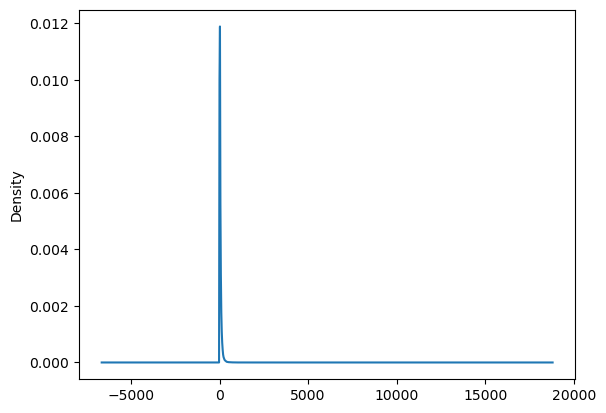

In [13]:
full_sold["DaysOnMarket"].plot.density()

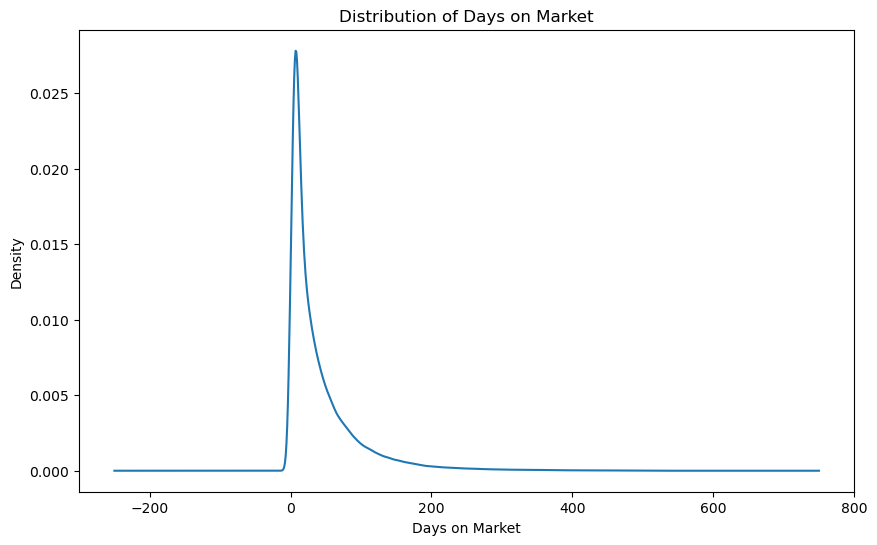

In [18]:
dom = full_sold.loc[
    (full_sold["DaysOnMarket"] >= 0) &
    (full_sold["DaysOnMarket"] <= 500),
    "DaysOnMarket"
].dropna()

dom.plot.density(figsize=(10, 6))

plt.xlabel("Days on Market")
plt.ylabel("Density")
plt.title("Distribution of Days on Market")
plt.show()

#### What percentage of homes sold above vs. below list price?

In [15]:
above = full_sold[full_sold["ClosePrice"] > full_sold["ListPrice"]]
below = full_sold[full_sold["ClosePrice"] < full_sold["ListPrice"]]

print(f"Percentage of sold listings above list price: {len(above)/len(full_sold)*100:.2f}%")
print(f"Percentage of sold listings below list price: {len(below)/len(full_sold)*100:.2f}%")

Percentage of sold listings above list price: 30.52%
Percentage of sold listings below list price: 38.46%


#### Are there any apparent date consistency issues (e.g., close date before listing date)?

In [16]:
list_dates = pd.to_datetime(full_sold['ListingContractDate'], errors='coerce')

close_dates = pd.to_datetime(full_sold['CloseDate'], errors='coerce')

bad_close = (
    list_dates.notna() &
    close_dates.notna() &
    (close_dates < list_dates)
)

print("Listings with CloseDate before ListingContractDate:")
print(bad_close.sum())

print("Percentage:")
print(round(bad_close.mean() * 100, 2), "%")

Listings with CloseDate before ListingContractDate:
133
Percentage:
0.02 %


#### Which counties have the highest median prices?

In [17]:
expensive_counties = full_listing.groupby("CountyOrParish")["ListPrice"].median().sort_values(ascending=False)
expensive_counties.head(10)

CountyOrParish
San Mateo          1450000.0
Santa Clara        1429888.0
Marin              1198500.0
Santa Cruz         1099000.0
San Francisco      1050000.0
Alameda             966444.0
Monterey            950000.0
San Luis Obispo     819000.0
San Diego           819000.0
Napa                799999.0
Name: ListPrice, dtype: float64